# 03 · The feature categories: demographics, APOE, cardiovascular, cognitive

**Goal.** For each group of inputs named in the project brief, show what is available, what it looks like, what cleaning it needs, and whether it carries any signal about future decline.

**Why.** The research question is whether cardiovascular and medical information adds something on top of cognition, demographics and APOE. Before building models we should look at each group honestly: how complete it is and how strongly it relates to the outcome on its own.

PET is covered in notebook 04.

**An important warning about this notebook.** The associations shown here are *descriptive*. They are not adjusted for confounders except where stated, and they do not show cause and effect. For example, if people with treated hypertension decline less, that does not mean blood-pressure tablets protect the brain. It may simply reflect who gets diagnosed and treated.

In [1]:
import sys, warnings
sys.path.insert(0, "../scripts")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import nacc_utils as nu

warnings.filterwarnings("ignore")
nu.set_style()
vm = pd.DataFrame(nu.VARIABLES).T
cols = [c for c in vm.index if c not in ("NACCID", "VISITDATE")]
df = nu.add_time(nu.clean(nu.load_uds(cols)))
base = df[df.NACCVNUM == 1].set_index("NACCID")
print(f"{len(df):,} visits; {len(base):,} first visits")

217,598 visits; 57,038 first visits


### A working outcome for this notebook only

To see whether a feature relates to decline we need *some* outcome. Here we use a simple one, so that the notebook has something to compare against:

> Among people **not demented at first visit**, did they receive a dementia diagnosis **within 3 years**? People whose status at 3 years is unknown (no event and last seen before 3 years) are left out.

This is a placeholder, not the project's final target. The final target is your decision (notebook 02, section 9).

In [2]:
HORIZON = 3.0
nd_ids = base.index[base.NACCUDSD.isin([1, 2, 3])]
fu = df[df.NACCID.isin(nd_ids) & (df.years > 0)]
t_event = fu[fu.NACCUDSD == 4].groupby("NACCID").years.min()
t_last = fu.groupby("NACCID").years.max()
label = pd.Series(np.nan, index=nd_ids)
label[t_last.index[t_last >= HORIZON]] = 0            # followed past the horizon
label[t_event.index[t_event <= HORIZON]] = 1          # converted before it
label[t_event.index[(t_event > HORIZON)]] = 0
cohort = base.loc[label.dropna().index].copy()
cohort["y"] = label.dropna().astype(int)
print(f"Working cohort: {len(cohort):,} people, {cohort.y.sum():,} converted to dementia within {HORIZON:.0f} years ({cohort.y.mean()*100:.1f}%)")
cohort.groupby(cohort.NACCUDSD.map(nu.DX_LABELS)).y.agg(Participants="size", Converted="sum", Rate_pct=lambda s: round(s.mean() * 100, 1))

Working cohort: 19,611 people, 2,833 converted to dementia within 3 years (14.4%)


,Participants,Converted,Rate_pct
NACCUDSD,,,
"Impaired, not MCI",1105,135,12.2
MCI,6032,2499,41.4
Normal,12474,199,1.6


Notice how different the rate is for people who start normal and people who start with MCI. Starting diagnosis is by far the strongest predictor, so in the plots below every comparison is shown **separately for normal and MCI**. Otherwise any feature that is more common in MCI would look predictive just because of that.

In [3]:
def rate_by(feature, bins=None, labels=None, data=cohort):
    """Conversion rate (%) by level of a feature, separately for normal and MCI at first visit."""
    x = data[feature] if bins is None else pd.cut(data[feature], bins=bins, labels=labels, right=False)
    out = {}
    for dx, name in [(1, "Normal at first visit"), (3, "MCI at first visit")]:
        m = data.NACCUDSD == dx
        g = data[m].groupby(x[m], observed=True).y.agg(["mean", "size"])
        out[name] = g
    return out

def plot_rates(ax, res, title, xlabel=""):
    names = list(res)
    cats = list(res[names[0]].index)
    w = 0.38
    for i, (name, color) in enumerate(zip(names, [nu.BLUE, nu.ORANGE])):
        g = res[name].reindex(cats)
        ax.bar(np.arange(len(cats)) + (i - 0.5) * w, g["mean"] * 100, width=w - 0.03, color=color, label=name)
    ax.set_xticks(range(len(cats)), [str(c) for c in cats], fontsize=8.5)
    ax.set_title(title, fontsize=10); ax.set_xlabel(xlabel); ax.grid(axis="x", visible=False)

## 1. Demographics

Age, sex, education, race and ethnicity. These are almost complete, need little cleaning, and are in every model as a matter of course: age is the strongest risk factor for dementia, and education is the usual proxy for "cognitive reserve".

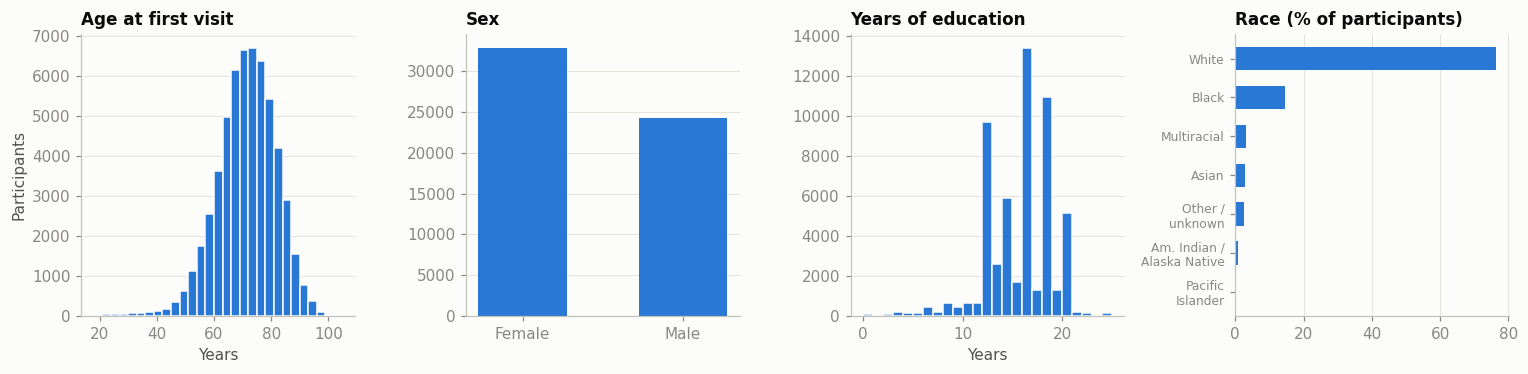

Age: median 71, middle half 65 to 78. Female 57.6%. Education median 16 years. White 76.3%, Black 14.5%, Hispanic 9.6%.


In [4]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
axes[0].hist(base.NACCAGE.dropna(), bins=np.arange(18, 106, 3), color=nu.BLUE, edgecolor="#fcfcfb", linewidth=1)
axes[0].set_title("Age at first visit"); axes[0].set_xlabel("Years"); axes[0].set_ylabel("Participants")
sx = base.NACCSEX.map({1: "Male", 2: "Female"}).value_counts()
axes[1].bar(sx.index, sx.values, color=nu.BLUE, width=0.55); axes[1].set_title("Sex")
ed = base.EDUC.dropna().clip(upper=24)
axes[2].hist(ed, bins=np.arange(0, 26, 1), color=nu.BLUE, edgecolor="#fcfcfb", linewidth=1); axes[2].set_title("Years of education"); axes[2].set_xlabel("Years")
race = base.NACCNIHR.map({1: "White", 2: "Black", 5: "Asian", 6: "Multiracial", 3: "Am. Indian /\nAlaska Native", 4: "Pacific\nIslander"}).fillna("Other /\nunknown").value_counts()
axes[3].barh(race.index[::-1], race.values[::-1] / len(base) * 100, color=nu.BLUE, height=0.6); axes[3].set_title("Race (% of participants)"); axes[3].tick_params(axis="y", labelsize=8)
for ax in axes: ax.grid(axis="x" if ax is not axes[3] else "y", visible=False)
fig.tight_layout(); nu.savefig(fig, "03_demographics"); plt.show()
print(f"Age: median {base.NACCAGE.median():.0f}, middle half {base.NACCAGE.quantile(.25):.0f} to {base.NACCAGE.quantile(.75):.0f}. "
      f"Female {nu.pct((base.NACCSEX==2).sum(), len(base))}%. Education median {base.EDUC.median():.0f} years. "
      f"White {nu.pct((base.NACCNIHR==1).sum(), len(base))}%, Black {nu.pct((base.NACCNIHR==2).sum(), len(base))}%, "
      f"Hispanic {nu.pct((base.NACCHISP==1).sum(), len(base))}%.")

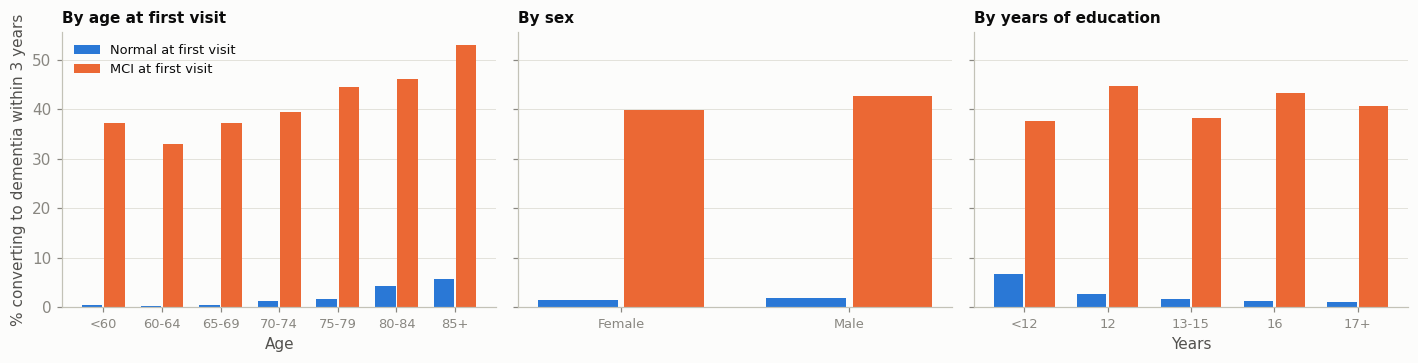

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), sharey=True)
plot_rates(axes[0], rate_by("NACCAGE", [0, 60, 65, 70, 75, 80, 85, 120], ["<60", "60-64", "65-69", "70-74", "75-79", "80-84", "85+"]), "By age at first visit", "Age")
cohort["sex"] = cohort.NACCSEX.map({1: "Male", 2: "Female"})
plot_rates(axes[1], rate_by("sex"), "By sex")
plot_rates(axes[2], rate_by("EDUC", [0, 12, 13, 16, 17, 40], ["<12", "12", "13-15", "16", "17+"]), "By years of education", "Years")
axes[0].set_ylabel("% converting to dementia within 3 years"); axes[0].legend(fontsize=8.5, loc="upper left")
fig.tight_layout(); nu.savefig(fig, "03_demographics_vs_outcome"); plt.show()

**What demographics contribute.**

* **Age** has a clear gradient in both groups. It will be one of the top features in any model, and it is a confounder for almost everything else: older people have more hypertension, more heart disease *and* more dementia. Any claim about another feature must be made after accounting for age.
* **Sex** and **education** show smaller differences.
* **The cohort is highly educated and mostly White.** Median education is 16 years (a university degree). A model trained here may not work as well for other groups. This belongs in the limitations, and it is a reason to report performance separately by sex, race and education group (a fairness check) during validation.

## 2. Genetics: APOE

The file contains the APOE genotype (`NACCAPOE`) and the count of e4 alleles (`NACCNE4S`). It also has flags for whether other genetic data exist elsewhere (GWAS, sequencing), but **not the genetic data themselves**. So "genetics" in this project means APOE, plus family history from form A3. The report should say exactly that.

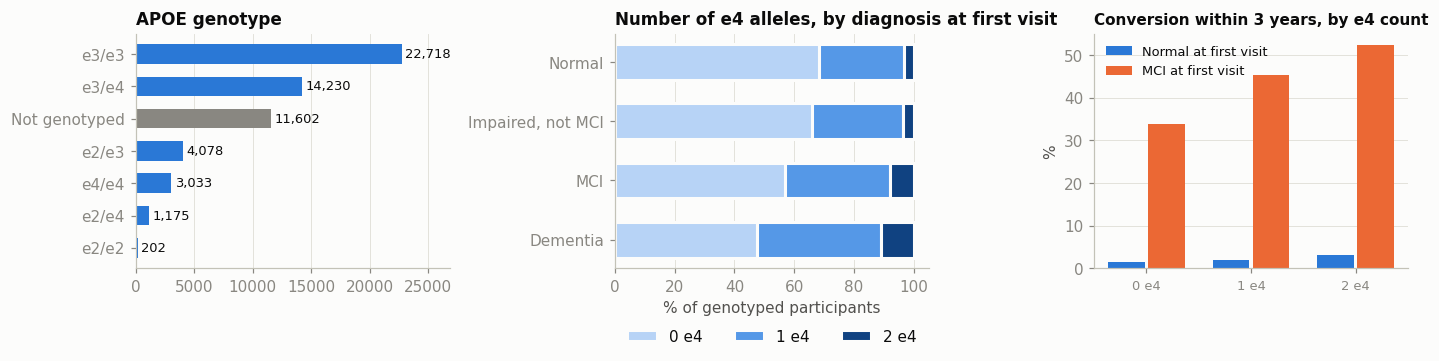

Genotyped: 45,436 of 57,038 (79.7%). At least one e4 among genotyped: 40.6%.


,Participants,% genotyped
NACCUDSD,,
Dementia,17658.0,76.4
"Impaired, not MCI",2644.0,77.0
MCI,12848.0,79.2
Normal,23885.0,82.6


In [6]:
geno = {1: "e3/e3", 2: "e3/e4", 3: "e2/e3", 4: "e4/e4", 5: "e2/e4", 6: "e2/e2"}
g = base.NACCAPOE.map(geno).fillna("Not genotyped").value_counts()
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].barh(g.index[::-1], g.values[::-1], color=[nu.MUTED if i == "Not genotyped" else nu.BLUE for i in g.index[::-1]], height=0.6)
for y, v in enumerate(g.values[::-1]): axes[0].text(v + 300, y, f"{v:,}", va="center", fontsize=8.5)
axes[0].set_xlim(0, g.max() * 1.18); axes[0].set_title("APOE genotype"); axes[0].grid(axis="y", visible=False)
e4_dx = pd.crosstab(base.NACCUDSD.map(nu.DX_LABELS), base.NACCNE4S, normalize="index").reindex([nu.DX_LABELS[k] for k in [1, 2, 3, 4]]) * 100
left = np.zeros(4)
for k, color in zip([0.0, 1.0, 2.0], ["#b7d3f6", "#5598e7", "#104281"]):
    axes[1].barh(e4_dx.index, e4_dx[k], left=left, color=color, label=f"{int(k)} e4", edgecolor="#fcfcfb", linewidth=2, height=0.6); left += e4_dx[k].values
axes[1].set_title("Number of e4 alleles, by diagnosis at first visit"); axes[1].set_xlabel("% of genotyped participants")
axes[1].legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.2)); axes[1].grid(axis="y", visible=False); axes[1].invert_yaxis()
cohort["e4"] = cohort.NACCNE4S.map({0: "0 e4", 1: "1 e4", 2: "2 e4"})
plot_rates(axes[2], rate_by("e4"), "Conversion within 3 years, by e4 count"); axes[2].set_ylabel("%"); axes[2].legend(fontsize=8.5)
fig.tight_layout(); nu.savefig(fig, "03_apoe"); plt.show()

geno_known = base.NACCAPOE.notna()
print(f"Genotyped: {geno_known.sum():,} of {len(base):,} ({nu.pct(geno_known.sum(), len(base))}%). "
      f"At least one e4 among genotyped: {nu.pct((base.NACCNE4S >= 1).sum(), geno_known.sum())}%.")
(base.groupby(base.NACCUDSD.map(nu.DX_LABELS)).apply(lambda d: pd.Series({"Participants": len(d), "% genotyped": nu.pct(d.NACCAPOE.notna().sum(), len(d))})))

**What APOE contributes.**

* The e4 allele is clearly more common in people with MCI and dementia, and conversion rates rise with each copy. This matches the literature, which is a good sign that the data and our cleaning are sound.
* **About one in five people has no genotype.** Whether someone was genotyped is not random (it depends on centre and on consent to a blood draw). The cleaning step must not silently fill these in with "0 copies". The usual choice is a separate "unknown" category, so the model can still use those people.
* APOE is fixed for life, so it never causes time leakage. The same value applies to every visit.

## 3. Cardiovascular and medical

This is the group the project is named after, and it is the most awkward to clean. It comes from four different forms:

| Source | What it holds | When it is collected |
|---|---|---|
| **B1** physical | Measured blood pressure, heart rate, height, weight, BMI | In-person visits |
| **A5** health history | Reported hypertension, diabetes, cholesterol, heart attack, atrial fibrillation, stroke, TIA, smoking, alcohol. Coded absent / recent / remote | First visits, and follow-ups in versions 1-2 |
| **D2** clinician-assessed conditions | The same conditions judged by the clinician, coded no / yes | Version 3 visits only |
| **A4** medications | Derived flags: on any blood-pressure drug, lipid-lowering drug, diabetes drug, anticoagulant | Every visit |

The brief warns: do not call every medical variable "cardiovascular". The map restricts this group to vascular risk factors, heart disease, cerebrovascular disease, vital signs and the drug classes that treat them.

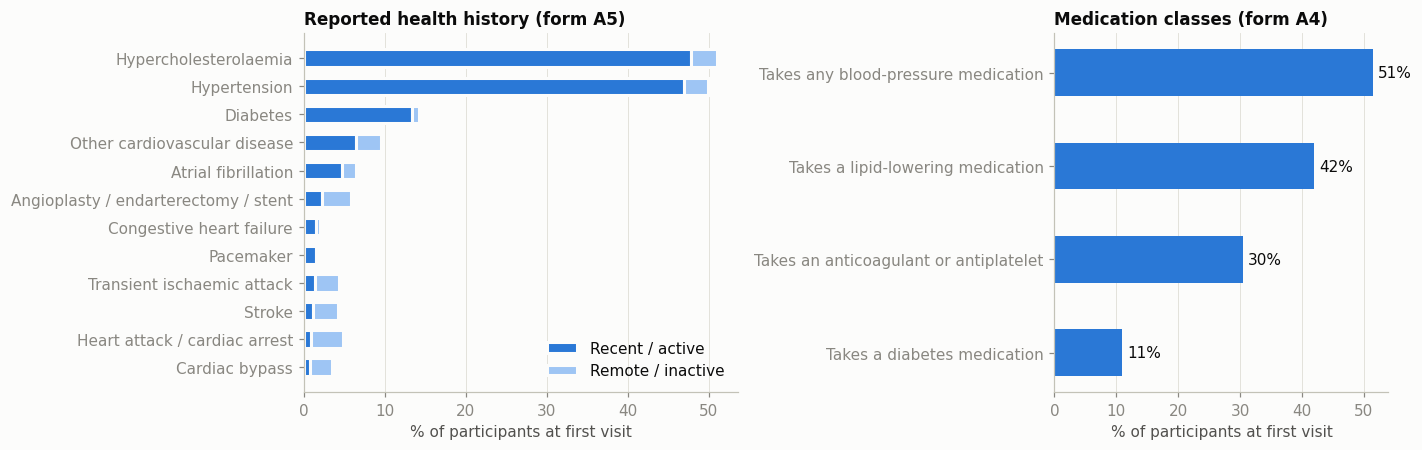

In [7]:
aru = ["HYPERTEN", "HYPERCHO", "DIABETES", "CVAFIB", "CVHATT", "CVANGIO", "CVBYPASS", "CVCHF", "CVPACE", "CVOTHR", "CBSTROKE", "CBTIA"]
prev = pd.DataFrame({"Recent / active": [(base[c] == 1).mean() * 100 for c in aru],
                     "Remote / inactive": [(base[c] == 2).mean() * 100 for c in aru]},
                    index=[vm.loc[c, "meaning"] for c in aru]).sort_values("Recent / active")
meds = pd.Series({vm.loc[c, "meaning"]: (base[c] == 1).mean() * 100 for c in ["NACCAHTN", "NACCLIPL", "NACCAC", "NACCDBMD"]}).sort_values()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1.3, 1]})
axes[0].barh(prev.index, prev["Recent / active"], color=nu.BLUE, label="Recent / active", height=0.62, edgecolor="#fcfcfb", linewidth=2)
axes[0].barh(prev.index, prev["Remote / inactive"], left=prev["Recent / active"], color="#9ec5f4", label="Remote / inactive", height=0.62, edgecolor="#fcfcfb", linewidth=2)
axes[0].set_xlabel("% of participants at first visit"); axes[0].set_title("Reported health history (form A5)"); axes[0].legend(loc="lower right")
axes[1].barh(meds.index, meds.values, color=nu.BLUE, height=0.5); axes[1].set_xlabel("% of participants at first visit"); axes[1].set_title("Medication classes (form A4)")
for y, v in enumerate(meds.values): axes[1].text(v + 0.8, y, f"{v:.0f}%", va="center")
for ax in axes: ax.grid(axis="y", visible=False)
fig.tight_layout(); nu.savefig(fig, "03_cardio_prevalence"); plt.show()

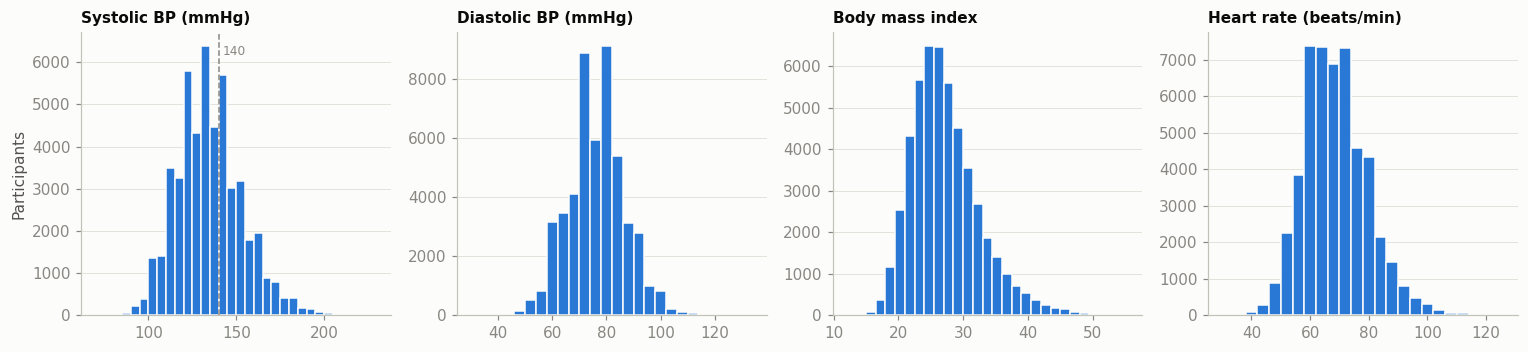

,count,mean,std,min,50%,max,% measured at first visit
BPSYS,49835.0,134.2,18.8,70.0,132.0,230.0,87.4
BPDIAS,49825.0,75.7,10.6,30.0,76.0,140.0,87.4
HRATE,50781.0,68.3,11.1,33.0,68.0,160.0,89.0
NACCBMI,50269.0,27.3,5.4,10.0,26.5,84.2,88.1


In [8]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.3))
for ax, (c, lab, bins) in zip(axes, [("BPSYS", "Systolic BP (mmHg)", np.arange(70, 235, 5)), ("BPDIAS", "Diastolic BP (mmHg)", np.arange(30, 135, 4)),
                                     ("NACCBMI", "Body mass index", np.arange(12, 56, 1.5)), ("HRATE", "Heart rate (beats/min)", np.arange(30, 130, 4))]):
    ax.hist(base[c].dropna(), bins=bins, color=nu.BLUE, edgecolor="#fcfcfb", linewidth=1)
    ax.set_title(lab, fontsize=10); ax.grid(axis="x", visible=False)
axes[0].set_ylabel("Participants"); axes[0].axvline(140, color=nu.MUTED, lw=1, ls="--"); axes[0].text(142, axes[0].get_ylim()[1] * 0.92, "140", color=nu.MUTED, fontsize=8)
fig.tight_layout(); nu.savefig(fig, "03_vitals"); plt.show()
vit = base[["BPSYS", "BPDIAS", "HRATE", "NACCBMI"]].describe().T[["count", "mean", "std", "min", "50%", "max"]].round(1)
vit["% measured at first visit"] = (vit["count"] / len(base) * 100).round(1)
vit

The measured values look physiologically sensible after cleaning (no systolic pressure of 888). Blood pressure is a single reading taken at a research visit, so it is noisy. Averaging over visits, or using the trend, is more informative than one reading.

### 3.1 The same condition is recorded on two forms

For a version 3 first visit, both A5 (reported) and D2 (clinician-assessed) exist. How often do they agree?

In [9]:
pairs = [("HYPERTEN", "HYPERT", "Hypertension"), ("HYPERCHO", "HYPCHOL", "High cholesterol"), ("DIABETES", "DIABET", "Diabetes"),
         ("CVAFIB", "AFIBRILL", "Atrial fibrillation"), ("CVCHF", "CONGHRT", "Heart failure")]
rows = []
for a5, d2, name in pairs:
    both = base[[a5, d2]].dropna()
    a = both[a5].isin([1, 2]); b = both[d2] >= 1
    rows.append({"Condition": name, "Visits with both forms": len(both), "% yes on A5 (recent or remote)": nu.pct(a.sum(), len(both)),
                 "% yes on D2": nu.pct(b.sum(), len(both)), "% agreement": nu.pct((a == b).sum(), len(both)),
                 "% recent on A5 that D2 confirms": nu.pct((b & (both[a5] == 1)).sum(), (both[a5] == 1).sum())})
pd.DataFrame(rows).set_index("Condition")

,Visits with both forms,% yes on A5 (recent or remote),% yes on D2,% agreement,% recent on A5 that D2 confirms
Condition,,,,,
Hypertension,22809,47.7,46.5,94.4,95.0
High cholesterol,22648,52.6,51.3,92.5,94.0
Diabetes,22779,15.4,15.2,98.4,96.0
Atrial fibrillation,22728,6.1,5.3,98.4,90.7
Heart failure,22804,1.4,1.2,99.5,86.9


Agreement is high but not perfect, because "remote / inactive" on A5 does not always count as a current condition on D2. This is a **harmonisation decision**: a single feature such as "hypertension: ever" has to be built from A5 where it exists and from D2 otherwise, and carried forward in time (once someone has had a stroke, they have always had a stroke).

### 3.2 Availability over time

Because A5 is not repeated at version 3 follow-ups, a per-visit cardiovascular feature is often blank. The chart shows, among follow-up visits, how often each source has a value.

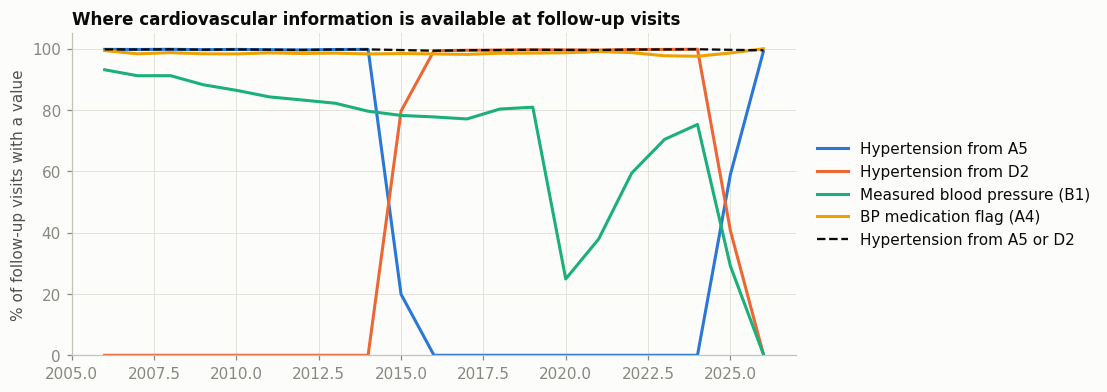

In [10]:
fuv = df[df.NACCVNUM > 1]
src = {"Hypertension from A5": "HYPERTEN", "Hypertension from D2": "HYPERT", "Measured blood pressure (B1)": "BPSYS", "BP medication flag (A4)": "NACCAHTN"}
avail = pd.DataFrame({k: fuv[v].notna().groupby(fuv.VISITDATE.dt.year).mean() * 100 for k, v in src.items()})
either = (fuv.HYPERTEN.notna() | fuv.HYPERT.notna()).groupby(fuv.VISITDATE.dt.year).mean() * 100
fig, ax = plt.subplots(figsize=(8.5, 3.8))
for (k, s), color in zip(avail.items(), [nu.BLUE, nu.ORANGE, nu.AQUA, nu.YELLOW]):
    ax.plot(s.index, s.values, color=color, label=k)
ax.plot(either.index, either.values, color=nu.INK, ls="--", lw=1.5, label="Hypertension from A5 or D2")
ax.set_ylim(0, 105); ax.set_ylabel("% of follow-up visits with a value"); ax.set_title("Where cardiovascular information is available at follow-up visits")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5)); nu.savefig(fig, "03_cardio_availability"); plt.show()

Combining A5 and D2 (dashed line) recovers nearly every visit. The medication flags are the most consistently available cardiovascular signal across the whole twenty years. Measured blood pressure drops in 2020-2021, when visits moved to the telephone during the pandemic.

### 3.3 Do cardiovascular factors relate to decline?

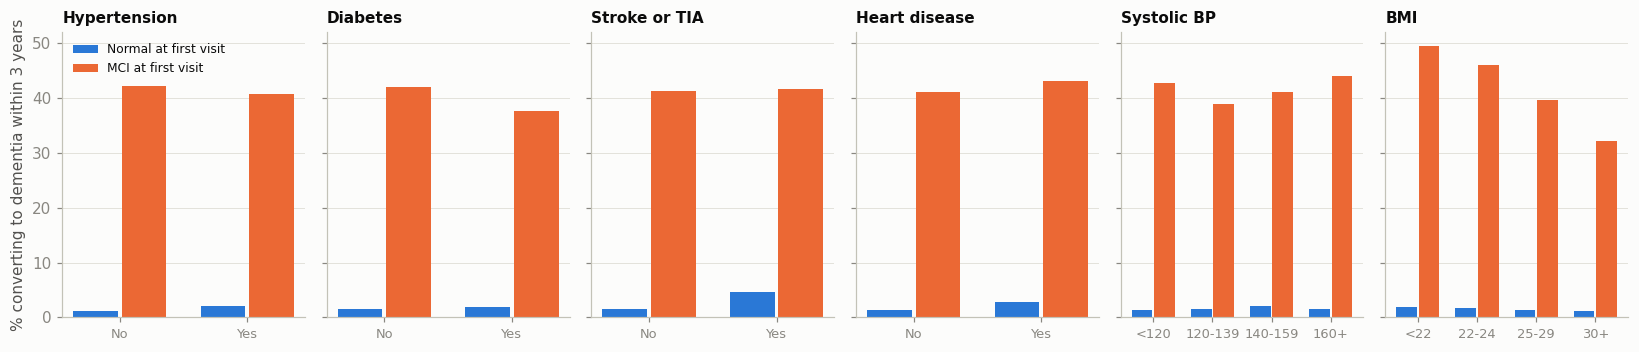

In [11]:
cohort["htn"] = np.where(cohort.HYPERTEN.isin([1, 2]), "Yes", np.where(cohort.HYPERTEN == 0, "No", None))
cohort["diab"] = np.where(cohort.DIABETES.isin([1, 2]), "Yes", np.where(cohort.DIABETES == 0, "No", None))
cohort["stroke"] = np.where(cohort.CBSTROKE.isin([1, 2]) | cohort.CBTIA.isin([1, 2]), "Yes", np.where(cohort.CBSTROKE == 0, "No", None))
cohort["heart"] = np.where(cohort[["CVHATT", "CVAFIB", "CVCHF", "CVBYPASS", "CVANGIO"]].isin([1, 2]).any(axis=1), "Yes", "No")
fig, axes = plt.subplots(1, 6, figsize=(15, 3.3), sharey=True)
plot_rates(axes[0], rate_by("htn"), "Hypertension")
plot_rates(axes[1], rate_by("diab"), "Diabetes")
plot_rates(axes[2], rate_by("stroke"), "Stroke or TIA")
plot_rates(axes[3], rate_by("heart"), "Heart disease")
plot_rates(axes[4], rate_by("BPSYS", [0, 120, 140, 160, 300], ["<120", "120-139", "140-159", "160+"]), "Systolic BP")
plot_rates(axes[5], rate_by("NACCBMI", [0, 22, 25, 30, 100], ["<22", "22-24", "25-29", "30+"]), "BMI")
axes[0].set_ylabel("% converting to dementia within 3 years"); axes[0].legend(fontsize=8, loc="upper left")
fig.tight_layout(); nu.savefig(fig, "03_cardio_vs_outcome"); plt.show()

**Read this carefully; it is the central question of the project.**

* The differences between "yes" and "no" are **small** compared with the difference between the blue and orange bars (starting diagnosis), and compared with the age and APOE gradients above.
* Some go in a direction that looks "wrong". Lower BMI goes with *more* conversion. This is well known: people lose weight in the years before a dementia diagnosis, so low BMI is partly an early *sign* of disease, not a cause. Similar "reverse" patterns are reported for blood pressure in late life.
* These bars are not adjusted for age. People with hypertension are older.

**The honest expectation** is that cardiovascular features will add a **modest** improvement over cognition, age and APOE, not a dramatic one. That is still a perfectly good finding for a final-year project, provided it is measured properly (an ablation: the same model with and without the cardiovascular group, on the same test set, with confidence intervals) and reported as it comes out. A result of "cardiovascular features added little once cognition was known" is a defensible scientific answer to research question 1.

Cardiovascular factors act over decades (mid-life hypertension matters more than late-life readings), and NACC participants enrol at a median age of about 71. This cohort cannot observe mid-life exposure. That is a limitation to state, and it is also why "ever had" and "duration" features may carry more signal than a single reading.

## 4. Cognitive

Three kinds of information sit in this group:

1. **Neuropsychological tests** (objective scores): memory, attention, processing speed, executive function, language, visuospatial.
2. **Function and behaviour** questionnaires answered by a study partner: FAQ (daily function), NPI-Q (behaviour), GDS (mood).
3. **CDR**, which is also our outcome.

### 4.1 The battery changed between versions

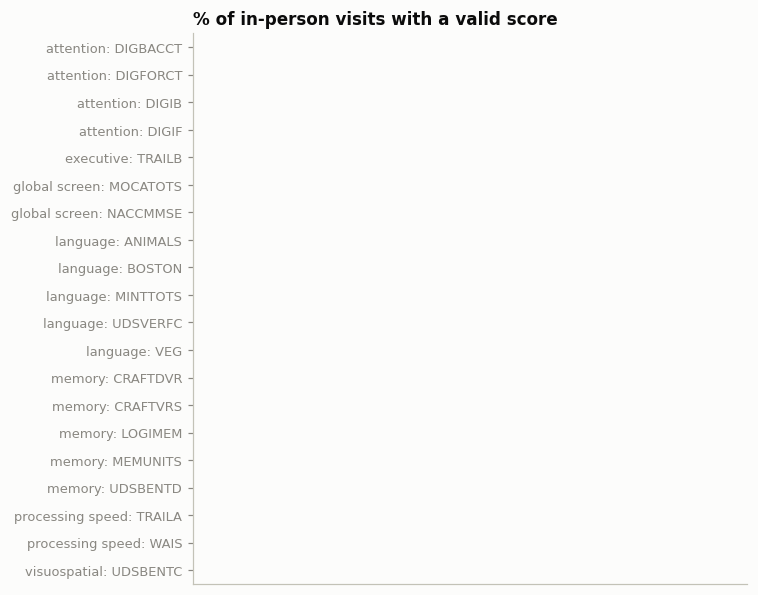

In [12]:
tests = vm[(vm.category == nu.COG) & (vm.kind == "continuous") & vm.subgroup.isin(
    ["global screen", "memory", "attention", "processing speed", "executive", "language", "visuospatial"])]
dfv = df[df.PACKET.isin(["I", "F", "I4"])].copy()
dfv["Version"] = dfv.FORMVER.map({1.0: "UDS v1-2", 2.0: "UDS v1-2", 3.0: "UDS v3", 3.2: "UDS v3", 4.0: "UDS v4"})
av = pd.DataFrame({c: dfv[c].notna().groupby(dfv.Version).mean() * 100 for c in tests.index}).T
av.index = [f"{tests.loc[c, 'subgroup']}: {c}" for c in av.index]
av = av.sort_index()
fig, ax = plt.subplots(figsize=(6.5, 6.5))
im = ax.imshow(av.values, cmap="Blues", vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(av.shape[1]), av.columns); ax.set_yticks(range(len(av)), av.index, fontsize=8.5); ax.grid(False)
for i in range(av.shape[0]):
    for j in range(av.shape[1]):
        ax.text(j, i, f"{av.values[i, j]:.0f}", ha="center", va="center", fontsize=8, color="white" if av.values[i, j] > 55 else nu.INK)
ax.set_title("% of in-person visits with a valid score"); nu.savefig(fig, "03_test_availability"); plt.show()

Only category fluency (animals, vegetables) and Trail Making A and B run through every version. Each cognitive **domain** is covered in every version, but by a different test:

| Domain | Versions 1-2 | Version 3 onward |
|---|---|---|
| Global screen | MMSE | MoCA |
| Story memory | Logical Memory | Craft Story |
| Attention | Digit Span | Number Span |
| Naming | Boston Naming | MINT |

**This is a real design decision.** Options, from simplest to most involved:

1. Use only the tests common to all versions, plus CDR. Simple and safe, but throws away memory tests, which are the most informative for Alzheimer's disease.
2. Convert each test to a **z-score** against cognitively normal participants (adjusting for age, sex and education), then average z-scores within a domain. Each person gets a "memory score", an "executive score" and so on, whichever test they took. This is the common approach in the NACC literature.
3. Use published **crosswalk** tables that convert version 3 scores to version 2 equivalents (NACC ran a crosswalk study for exactly this purpose).
4. Restrict the study to version 3 visits (2015 onward). Clean, and it matches the PET era, but it shortens the available history.

Option 2 is the recommended default; it must be fitted on training data only.

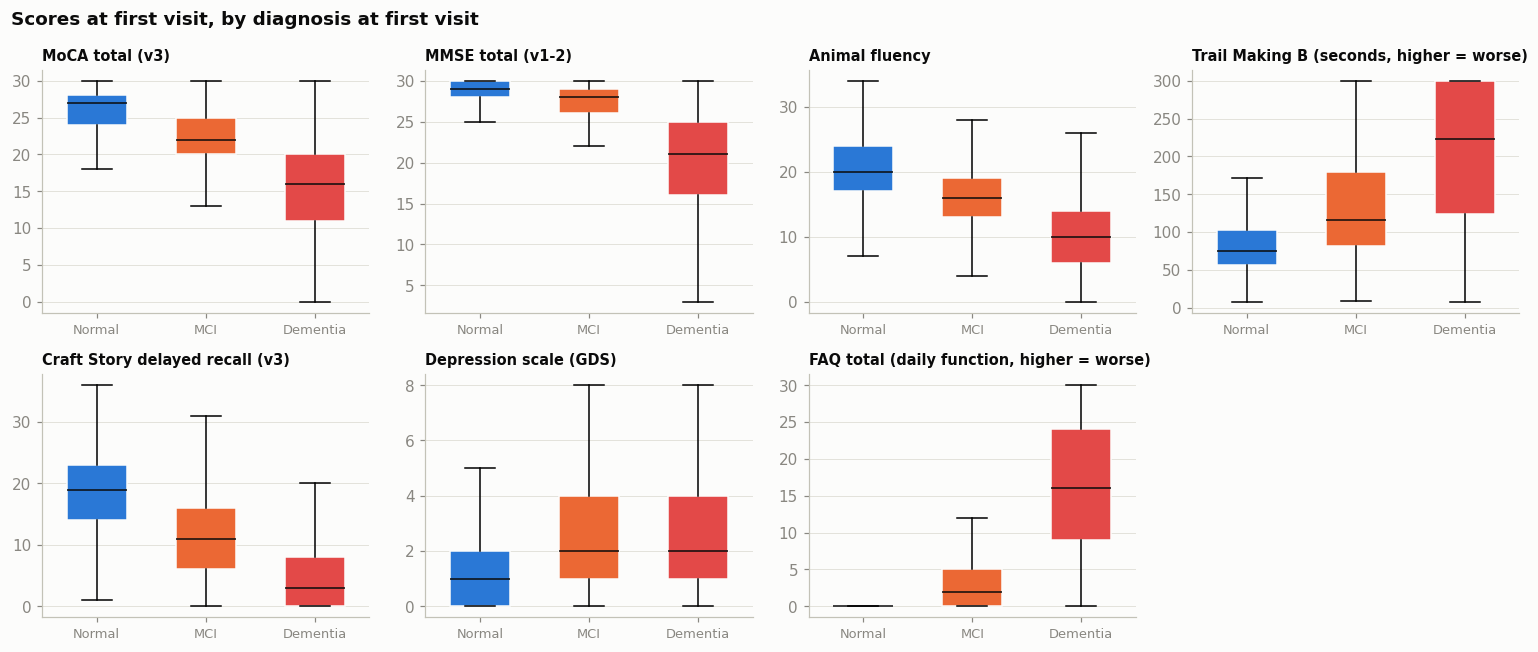

In [13]:
show = [("MOCATOTS", "MoCA total (v3)"), ("NACCMMSE", "MMSE total (v1-2)"), ("ANIMALS", "Animal fluency"), ("TRAILB", "Trail Making B (seconds, higher = worse)"),
        ("CRAFTDVR", "Craft Story delayed recall (v3)"), ("NACCGDS", "Depression scale (GDS)")]
base["FAQ"] = base[nu.FAQ_ITEMS].sum(axis=1, min_count=8)
show.append(("FAQ", "FAQ total (daily function, higher = worse)"))
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, (c, lab) in zip(axes.ravel(), show):
    data = [base.loc[base.NACCUDSD == k, c].dropna() for k in [1, 3, 4]]
    bp = ax.boxplot(data, patch_artist=True, showfliers=False, widths=0.55, medianprops=dict(color=nu.INK))
    for patch, k in zip(bp["boxes"], [1, 3, 4]): patch.set(facecolor=nu.DX_COLORS[k], edgecolor="#fcfcfb")
    ax.set_xticks([1, 2, 3], ["Normal", "MCI", "Dementia"], fontsize=8.5); ax.set_title(lab, fontsize=9.5); ax.grid(axis="x", visible=False)
axes.ravel()[-1].axis("off")
fig.suptitle("Scores at first visit, by diagnosis at first visit", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); nu.savefig(fig, "03_cognitive_by_dx"); plt.show()

Cognitive scores separate the diagnostic groups strongly, as expected: the diagnosis is partly *made from* these scores. Two consequences:

* Cognition will dominate any model. A fair test of the other categories is whether they add anything **after** cognition is included.
* The FAQ (daily function) almost defines the line between MCI and dementia, because dementia is diagnosed when function is impaired. That is why the map marks FAQ items as **proximal**. Including FAQ will raise accuracy, but partly by reading the clinician's mind.

### 4.2 Not everyone can complete a test

In [14]:
rawt = nu.load_uds(["NACCVNUM", "NACCUDSD", "TRAILB", "ANIMALS", "MOCATOTS", "CRAFTDVR"])
rawt = rawt[(rawt.NACCVNUM == 1) & rawt.NACCUDSD.isin([1, 3, 4])]
rows = {}
for c, codes in [("TRAILB", [995, 996, 997, 998]), ("ANIMALS", [95, 96, 97, 98]), ("CRAFTDVR", [95, 96, 97, 98])]:
    given = rawt[rawt[c] != -4]
    rows[vm.loc[c, "meaning"]] = (given[c].isin(codes).groupby(given.NACCUDSD.map(nu.DX_LABELS)).mean() * 100).round(1)
pd.DataFrame(rows).T[["Normal", "MCI", "Dementia"]].rename_axis("% of people given the test who could not complete it")

NACCUDSD,Normal,MCI,Dementia
% of people given the test who could not complete it,,,
"Trail Making B, seconds (higher = worse)",4.2,8.1,44.5
Category fluency: animals in 60 s,2.5,1.9,13.8
"Craft Story delayed recall, verbatim; v3",4.4,4.4,17.4


A score can be missing because the person was **too impaired to do the test**. That kind of missingness is informative: it is itself a sign of severity. If we impute the average score for these people, we tell the model that a severely impaired person is average. Better options are a "could not complete" indicator next to each test, or assigning the worst possible score. This is a cleaning decision.

### 4.3 Tests are strongly correlated with each other

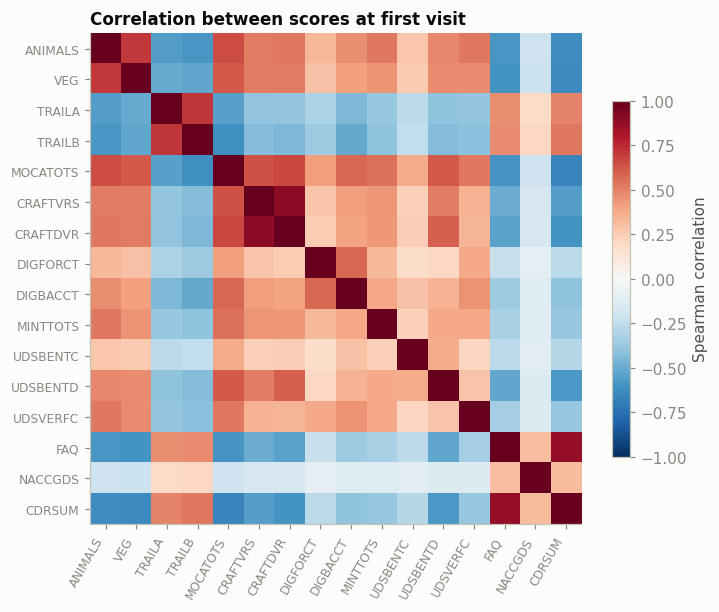

In [15]:
tcols = ["ANIMALS", "VEG", "TRAILA", "TRAILB", "MOCATOTS", "CRAFTVRS", "CRAFTDVR", "DIGFORCT", "DIGBACCT", "MINTTOTS", "UDSBENTC", "UDSBENTD", "UDSVERFC", "FAQ", "NACCGDS", "CDRSUM"]
corr = base[tcols].corr(method="spearman")
fig, ax = plt.subplots(figsize=(7.2, 6))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(tcols)), tcols, rotation=60, ha="right", fontsize=8); ax.set_yticks(range(len(tcols)), tcols, fontsize=8); ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.7, label="Spearman correlation"); ax.set_title("Correlation between scores at first visit")
nu.savefig(fig, "03_test_correlation"); plt.show()

Many tests move together. This matters for **explainability**: SHAP splits credit between correlated features more or less arbitrarily, so "Trail B was the third most important feature" is not a stable statement. Grouping tests into domain scores before modelling makes the explanations more robust, and easier to present to a clinician.

## 5. A first, rough look at what each category adds

To make the comparison concrete, here is a deliberately simple experiment on the working cohort:

* model: logistic regression (the simplest reasonable baseline);
* missing values: median fill plus a "was missing" indicator, fitted inside each training fold only;
* evaluation: 5-fold cross-validation, each person in exactly one fold, AUROC;
* feature groups are added one at a time.

**This is a preview, not a result.** It uses first-visit data only, a placeholder target, no tuning and no held-out test set. Its purpose is to show the *method* for answering "does this category help?" and to set expectations.

In [16]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, average_precision_score

X = cohort.copy()
X["female"] = (X.NACCSEX == 2).astype(float)
X["white"] = (X.NACCNIHR == 1).astype(float); X["hispanic"] = X.NACCHISP
X["e4_1"] = (X.NACCNE4S == 1).astype(float); X["e4_2"] = (X.NACCNE4S == 2).astype(float); X["apoe_unknown"] = X.NACCNE4S.isna().astype(float)
for c in aru + ["ALCOHOL"]:
    X[c + "_ever"] = X[c].isin([1, 2]).astype(float).where(X[c].notna())
X["FAQ"] = X[nu.FAQ_ITEMS].sum(axis=1, min_count=8)
groups = {
    "Demographics": ["NACCAGE", "female", "EDUC", "white", "hispanic"],
    "APOE and family history": ["e4_1", "e4_2", "apoe_unknown", "NACCFAM"],
    "Cardiovascular / medical": [c + "_ever" for c in aru] + ["BPSYS", "BPDIAS", "HRATE", "NACCBMI", "TOBAC100", "SMOKYRS", "NACCAHTN", "NACCLIPL", "NACCDBMD", "NACCAC"],
    "Cognitive tests": ["ANIMALS", "VEG", "TRAILA", "TRAILB", "NACCMMSE", "MOCATOTS", "LOGIMEM", "MEMUNITS", "CRAFTVRS", "CRAFTDVR", "DIGIF", "DIGIB", "DIGFORCT", "DIGBACCT", "NACCGDS"],
    "CDR-SB and diagnosis at index": ["CDRSUM", "is_mci"],
    "Daily function (FAQ, proximal)": ["FAQ"],
}
X["is_mci"] = (X.NACCUDSD == 3).astype(float)
y = X.y.values
cv = StratifiedKFold(5, shuffle=True, random_state=0)

def evaluate(features):
    model = make_pipeline(SimpleImputer(strategy="median", add_indicator=True), StandardScaler(), LogisticRegression(max_iter=2000, C=0.5))
    p = cross_val_predict(model, X[features].astype(float), y, cv=cv, method="predict_proba")[:, 1]
    return roc_auc_score(y, p), average_precision_score(y, p)

rows, used = [], []
for name, feats in groups.items():
    alone = evaluate(feats)
    used = used + feats
    cum = evaluate(used)
    rows.append({"Feature group": name, "Features": len(feats), "AUROC alone": round(alone[0], 3),
                 "AUROC, cumulative": round(cum[0], 3), "AUPRC, cumulative": round(cum[1], 3)})
res = pd.DataFrame(rows).set_index("Feature group")
print(f"Outcome rate (the AUPRC of a random guess): {y.mean():.3f}")
res

Outcome rate (the AUPRC of a random guess): 0.144


,Features,AUROC alone,"AUROC, cumulative","AUPRC, cumulative"
Feature group,,,,
Demographics,5,0.646,0.646,0.218
APOE and family history,4,0.633,0.703,0.273
Cardiovascular / medical,22,0.620,0.719,0.295
Cognitive tests,15,0.888,0.905,0.646
CDR-SB and diagnosis at index,2,0.902,0.937,0.722
"Daily function (FAQ, proximal)",1,0.832,0.940,0.728


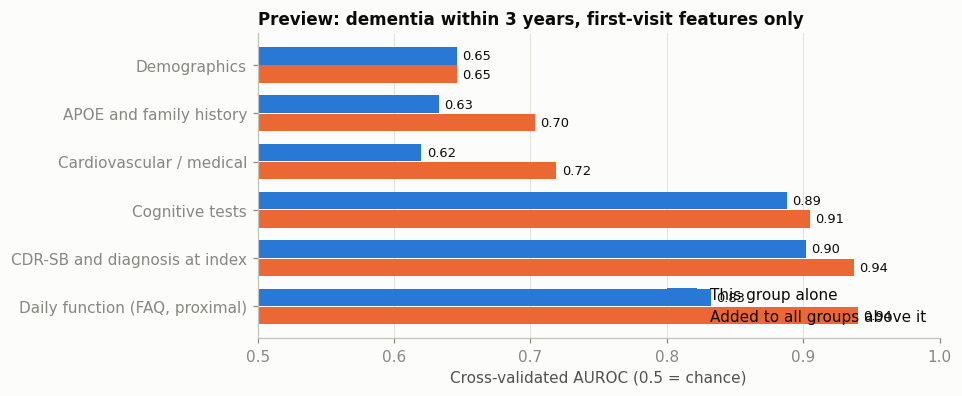

In [17]:
fig, ax = plt.subplots(figsize=(8, 3.6))
ypos = np.arange(len(res))[::-1]
ax.barh(ypos + 0.19, res["AUROC alone"], height=0.36, color=nu.BLUE, label="This group alone")
ax.barh(ypos - 0.19, res["AUROC, cumulative"], height=0.36, color=nu.ORANGE, label="Added to all groups above it")
for yv, a, c in zip(ypos, res["AUROC alone"], res["AUROC, cumulative"]):
    ax.text(a + 0.004, yv + 0.19, f"{a:.2f}", va="center", fontsize=8.5); ax.text(c + 0.004, yv - 0.19, f"{c:.2f}", va="center", fontsize=8.5)
ax.set_yticks(ypos, res.index); ax.set_xlim(0.5, 1.0); ax.set_xlabel("Cross-validated AUROC (0.5 = chance)"); ax.grid(axis="y", visible=False)
ax.set_title("Preview: dementia within 3 years, first-visit features only"); ax.legend(loc="lower right")
nu.savefig(fig, "03_category_preview"); plt.show()

**How to read the preview.**

* "Alone" asks: if this were the only information, how well could we rank people by risk?
* "Cumulative" asks: what does this group add on top of everything listed above it?
* Cardiovascular features carry some signal on their own, mostly because they travel with age. Their *added* value once demographics and APOE are in is the number to watch, and here it is small.
* Cognitive tests and CDR-SB at the index visit produce the big jump. That is expected and is not a discovery.

The order in which groups are added changes the "added value" of each. The proper experiment in Phase 3 removes one group at a time from the full model (ablation), repeats it over several random splits, and reports confidence intervals.

## 6. Summary and decisions

| Category | Available for | Main cleaning issue | What it is likely to contribute |
|---|---|---|---|
| Demographics | ~100% | None of note | Strong (age); needed as confounders in every model |
| APOE | ~80% genotyped | Not-genotyped is not random; keep as its own category | Clear, well-established signal |
| Family history | ~90% | Unknown codes | Small |
| Cardiovascular / medical | History ~99% at first visit, ~60% of all visits; BP ~87% of first visits | Two forms (A5, D2) to merge; carry forward; version 4 names differ | Modest added value expected; this is the research question |
| Cognitive tests | Depends on version (40-95%) | Battery changed at version 3; "could not complete" is informative | Dominant |
| Function (FAQ), independence | ~90% | Proximal to the diagnosis | Large, but arguably circular |

### Decisions for the team

1. **Harmonising cognitive tests:** common tests only, domain z-scores (recommended), crosswalk, or version 3 only.
2. **Handling "could not complete":** indicator variable, worst score, or both.
3. **One cardiovascular definition per condition:** "ever" (recommended, from A5 or D2, carried forward) versus "active now".
4. **Derived cardiovascular features:** for example, a count of vascular risk factors, pulse pressure (systolic minus diastolic), mean blood pressure over prior visits. Each one needs a short clinical justification.
5. **APOE not genotyped:** keep as an "unknown" category (recommended) or restrict the cohort to genotyped people.
6. **Proximal variables (FAQ, independence, memory complaint, Alzheimer's medication):** include, exclude, or report both ways (recommended: both, so readers see how much of the accuracy depends on them).